# 🌿 Fine-Tune Qwen3-VL-2B on Plant Disease Dataset using Unsloth + LoRA

**Model:** `Qwen/Qwen3-VL-2B-Instruct`

**Dataset:** `Rady10/Plant-Diseases-Image-Text-Pairs` (50K samples)

**Strategy:** Train 10K samples at a time, save adapter after each chunk (5 rounds total)

**Checkpointing:** Each round is pushed to 🤗 Hugging Face Hub. On failure, re-run resumes from the last completed round.

**Framework:** Unsloth (2x faster, 70% less VRAM)

## 1 - Setup & Dependencies

In [1]:
%%capture
%uv pip install --upgrade --force-reinstall --no-cache-dir unsloth unsloth_zoo
%uv pip install -q datasets trl evaluate rouge_score huggingface_hub

In [2]:
%uv pip install unsloth

Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 40ms
Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch
import time
import os
import gc
from datasets import load_dataset
from huggingface_hub import login, HfApi, list_repo_files, snapshot_download

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


## 1.5 - Hugging Face Hub Login & Checkpoint Config

In [7]:
# Login to Hugging Face (will prompt for token if not already logged in)
login()

# ── Configuration ──
HF_USERNAME = "Rady10"
HF_CHECKPOINT_REPO = f"{HF_USERNAME}/Plant-Disease-Qwen3VL-2B-Checkpoints"

# Create the checkpoint repo if it doesn't exist
api = HfApi()
try:
    api.repo_info(HF_CHECKPOINT_REPO)
    print(f"✅ Checkpoint repo exists: {HF_CHECKPOINT_REPO}")
except Exception:
    api.create_repo(HF_CHECKPOINT_REPO, private=True)
    print(f"✅ Created checkpoint repo: {HF_CHECKPOINT_REPO} (private)")

def get_completed_rounds():
    """Check HF Hub for already-completed training rounds."""
    try:
        files = list_repo_files(HF_CHECKPOINT_REPO)
        completed = set()
        for f in files:
            # Look for adapter_config.json inside round_X/ folders
            if f.startswith("round_") and f.endswith("adapter_config.json"):
                round_num = int(f.split("/")[0].replace("round_", ""))
                completed.add(round_num)
        return completed
    except Exception:
        return set()

completed = get_completed_rounds()
if completed:
    print(f"📦 Found completed rounds on Hub: {sorted(completed)}")
else:
    print("📦 No previous checkpoints found on Hub – starting fresh")

✅ Checkpoint repo exists: Rady10/Plant-Disease-Qwen3VL-2B-Checkpoints
📦 Found completed rounds on Hub: [1, 2, 3, 4]


## 2 - Load Model with Unsloth

In [10]:
from unsloth import FastVisionModel

MODEL_NAME = "unsloth/Qwen3-VL-2B-Instruct"
MAX_SEQ_LENGTH = 2048

model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    dtype=None,  # auto detect
)

print(f"✅ Model loaded: {MODEL_NAME}")

model.safetensors:   0%|          | 0.00/2.41G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

✅ Model loaded: unsloth/Qwen3-VL-2B-Instruct
==((====))==  Unsloth 2026.4.1: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

✅ Model loaded: unsloth/Qwen3-VL-2B-Instruct


## 3 - Apply LoRA

In [11]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
    target_modules="all-linear",
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Trainable: 23,724,032 / 1,528,401,920 (1.55%)


## 3.5 - Resume from Hub Checkpoint (if available)

If previous rounds were completed, download the latest checkpoint and load the adapter weights so training continues from where it left off.

In [12]:
ADAPTER_BASE = "./plant_disease_adapter"
os.makedirs(ADAPTER_BASE, exist_ok=True)

completed_rounds = get_completed_rounds()

if completed_rounds:
    resume_from = max(completed_rounds)
    resume_path = f"{ADAPTER_BASE}/round_{resume_from}"

    print(f"⬇️  Downloading checkpoint from round {resume_from} to resume...")
    snapshot_download(
        repo_id=HF_CHECKPOINT_REPO,
        allow_patterns=f"round_{resume_from}/*",
        local_dir=ADAPTER_BASE,
    )

    # Load the adapter weights from the checkpoint
    from peft import set_peft_model_state_dict
    import safetensors.torch

    adapter_file = os.path.join(resume_path, "adapter_model.safetensors")
    if not os.path.exists(adapter_file):
        adapter_file = os.path.join(resume_path, "adapter_model.bin")

    if os.path.exists(adapter_file):
        print(f"🔄 Loading adapter weights from round {resume_from}...")
        if adapter_file.endswith(".safetensors"):
            state_dict = safetensors.torch.load_file(adapter_file)
        else:
            state_dict = torch.load(adapter_file, map_location="cpu")
        set_peft_model_state_dict(model, state_dict)
        print(f"✅ Resumed from round {resume_from}")
    else:
        print(f"⚠️ Adapter file not found in {resume_path}, starting fresh")
        completed_rounds = set()
else:
    print("🆕 Starting training from scratch")

⬇️  Downloading checkpoint from round 4 to resume...


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

🔄 Loading adapter weights from round 4...
✅ Resumed from round 4


## 4 - Load & Prepare Dataset

In [13]:
dataset = load_dataset("Rady10/Plant-Diseases-Image-Text-Pairs", split="train")
print(f"Total dataset size: {len(dataset)}")
print(f"Features: {dataset.features}")

# Shuffle and take 50K
TOTAL_SAMPLES = 100000
dataset = dataset.shuffle(seed=42).select(range(min(TOTAL_SAMPLES, len(dataset))))
print(f"Selected: {len(dataset)} samples")

README.md:   0%|          | 0.00/326 [00:00<?, ?B/s]

data/train-00000-of-00013.parquet:   0%|          | 0.00/437M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/440M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/460M [00:00<?, ?B/s]

data/train-00003-of-00013.parquet:   0%|          | 0.00/434M [00:00<?, ?B/s]

...

data/train-00010-of-00013.parquet:   0%|          | 0.00/430M [00:00<?, ?B/s]

data/train-00011-of-00013.parquet:   0%|          | 0.00/453M [00:00<?, ?B/s]

data/train-00012-of-00013.parquet:   0%|          | 0.00/436M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/186746 [00:00<?, ? examples/s]

Total dataset size: 186746
Features: {'image': Image(mode=None, decode=True), 'text': Value('string')}
Selected: 50000 samples


In [ ]:
# Preview
for i in range(2):
    ex = dataset[i]
    print(f"\n{'='*80}")
    print(f"Example {i+1} | Image size: {ex['image'].size}")
    print(f"Text (first 200 chars): {ex['text'][:200]}...")
    display(ex['image'].resize((250, 250)))

In [14]:
INSTRUCTION = "You are an expert in plant pathology and entomology. Analyze this image and identify the disease or pest, then provide a detailed description of symptoms, characteristics, and morphological features."

def convert_to_conversation(sample):
    """Convert dataset sample to Unsloth conversation format."""
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": INSTRUCTION},
                {"type": "image", "image": sample["image"]},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": sample["text"]},
            ],
        },
    ]
    return {"messages": conversation}

# Test format
sample = convert_to_conversation(dataset[0])
print("User:", sample["messages"][0]["content"][0]["text"][:80], "...")
print("Assistant:", sample["messages"][1]["content"][0]["text"][:80], "...")
print("\n✅ Conversation format ready")

User: You are an expert in plant pathology and entomology. Analyze this image and iden ...
Assistant: By observing the image, I find some light green spots on the surface of the leav ...

✅ Conversation format ready


## 5 - Zero-Shot Test (Before Fine-Tuning)

In [ ]:
from transformers import TextStreamer

FastVisionModel.for_inference(model)

for idx in range(2):
    image = dataset[idx]["image"]
    gt = dataset[idx]["text"][:200]

    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": INSTRUCTION},
        ]}
    ]

    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tokenizer(
        image, input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    print(f"\n{'='*80}")
    print(f"📝 Example {idx+1}")
    display(image.resize((200, 200)))
    print(f"\n✅ Ground Truth: {gt}...")
    print(f"\n🤖 Zero-Shot:")

    text_streamer = TextStreamer(tokenizer, skip_prompt=True)
    _ = model.generate(
        **inputs,
        streamer=text_streamer,
        max_new_tokens=200,
        use_cache=True,
        temperature=1.5,
        min_p=0.1,
    )

## 6 - Training: 10K Chunks × 5 Rounds (with HF Hub Checkpointing)

Train on 10K samples at a time. After each round:
1. Save adapter **locally**
2. **Push to Hugging Face Hub** → `Rady10/Plant-Disease-Qwen3VL-2B-Checkpoints`

On re-run, already-completed rounds are **automatically skipped**.

| Round | Samples     | Hub Path                  |
|-------|-------------|---------------------------|
| 1     | 0 - 9,999   | `round_1/`               |
| 2     | 10K - 19,999| `round_2/`               |
| 3     | 20K - 29,999| `round_3/`               |
| 4     | 30K - 39,999| `round_4/`               |
| 5     | 40K - 49,999| `round_5/`               |

In [15]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

CHUNK_SIZE = 10000
NUM_CHUNKS = 5

total_start = time.time()

for chunk_idx in range(NUM_CHUNKS):
    round_num = chunk_idx + 1
    start_idx = chunk_idx * CHUNK_SIZE
    end_idx = min(start_idx + CHUNK_SIZE, len(dataset))

    # Skip already-completed rounds
    if round_num in completed_rounds:
        print(f"\n{'='*80}")
        print(f"⏭️  ROUND {round_num}/{NUM_CHUNKS}: SKIPPED (already on Hub)")
        print(f"{'='*80}")
        continue

    print(f"\n{'='*80}")
    print(f"🚀 ROUND {round_num}/{NUM_CHUNKS}: samples {start_idx:,} to {end_idx-1:,}")
    print(f"{'='*80}")

    # Select chunk and convert to conversation format
    chunk_data = dataset.select(range(start_idx, end_idx))
    converted_chunk = [convert_to_conversation(sample) for sample in chunk_data]

    print(f"Chunk size: {len(converted_chunk)} samples")

    # Enable training mode
    FastVisionModel.for_training(model)

    # Create trainer
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        data_collator=UnslothVisionDataCollator(model, tokenizer),
        train_dataset=converted_chunk,
        args=SFTConfig(
            output_dir=f"./outputs_round_{round_num}",
            num_train_epochs=1,
            per_device_train_batch_size=2,
            gradient_accumulation_steps=4,
            learning_rate=2e-4,
            lr_scheduler_type="linear",
            warmup_steps=5,
            weight_decay=0.01,
            fp16=not torch.cuda.is_bf16_supported(),
            bf16=torch.cuda.is_bf16_supported(),
            logging_steps=10,
            optim="adamw_8bit",
            seed=3407,
            report_to="none",
            remove_unused_columns=False,
            dataset_text_field="",
            dataset_kwargs={"skip_prepare_dataset": True},
            dataset_num_proc=4,
            max_seq_length=MAX_SEQ_LENGTH,
        ),
    )

    # Train
    chunk_start = time.time()
    trainer.train()
    chunk_time = time.time() - chunk_start

    print(f"\n⏱️ Round {round_num} completed in {chunk_time/60:.1f} minutes")

    # Save adapter locally
    adapter_path = f"{ADAPTER_BASE}/round_{round_num}"
    model.save_pretrained(adapter_path)
    tokenizer.save_pretrained(adapter_path)
    print(f"✅ Adapter saved locally: {adapter_path}")

    # Push checkpoint to Hugging Face Hub
    print(f"☁️  Uploading round {round_num} checkpoint to HF Hub...")
    api.upload_folder(
        folder_path=adapter_path,
        path_in_repo=f"round_{round_num}",
        repo_id=HF_CHECKPOINT_REPO,
        commit_message=f"Round {round_num}/{NUM_CHUNKS} – samples {start_idx:,}-{end_idx-1:,}",
    )
    print(f"✅ Round {round_num} checkpoint pushed to: {HF_CHECKPOINT_REPO}/round_{round_num}")

    # Clean up
    del trainer, converted_chunk, chunk_data
    gc.collect()
    torch.cuda.empty_cache()

total_time = time.time() - total_start
print(f"\n{'='*80}")
print(f"🏁 ALL {NUM_CHUNKS} ROUNDS COMPLETE in {total_time/60:.1f} minutes")
print(f"{'='*80}")


⏭️  ROUND 1/5: SKIPPED (already on Hub)

⏭️  ROUND 2/5: SKIPPED (already on Hub)

⏭️  ROUND 3/5: SKIPPED (already on Hub)

⏭️  ROUND 4/5: SKIPPED (already on Hub)

🚀 ROUND 5/5: samples 40,000 to 49,999
Chunk size: 10000 samples
Unsloth: Model does not have a default image size - using 512


[accelerate.utils.other|WARNING][RANK 0] Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 1 | Total steps = 1,250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 23,724,032 of 2,151,256,064 (1.10% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,0.013905
20,0.021553
30,0.025392
40,0.029832
50,0.022965
60,0.019400
70,0.027101
80,0.027832
90,0.026603
100,0.028357



⏱️ Round 5 completed in 84.8 minutes
✅ Adapter saved locally: ./plant_disease_adapter/round_5
☁️  Uploading round 5 checkpoint to HF Hub...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Round 5 checkpoint pushed to: Rady10/Plant-Disease-Qwen3VL-2B-Checkpoints/round_5

🏁 ALL 5 ROUNDS COMPLETE in 85.3 minutes


## 7 - Save Final Adapter (Local + Hub)

In [16]:
# The model now has all 50K samples trained.
# Save the final combined adapter locally.
FINAL_ADAPTER = f"{ADAPTER_BASE}/final_50k"
model.save_pretrained(FINAL_ADAPTER)
tokenizer.save_pretrained(FINAL_ADAPTER)
print(f"✅ Final adapter saved locally: {FINAL_ADAPTER}")

# Push final adapter to Hub
print("☁️  Uploading final adapter to HF Hub...")
api.upload_folder(
    folder_path=FINAL_ADAPTER,
    path_in_repo="final_50k",
    repo_id=HF_CHECKPOINT_REPO,
    commit_message="Final adapter after all 50K samples",
)
print(f"✅ Final adapter pushed to: {HF_CHECKPOINT_REPO}/final_50k")

# List all saved adapters
print("\n📁 All saved adapters:")
for d in sorted(os.listdir(ADAPTER_BASE)):
    path = os.path.join(ADAPTER_BASE, d)
    if os.path.isdir(path):
        size_mb = sum(os.path.getsize(os.path.join(path, f)) for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))) / 1e6
        print(f"  📂 {d} ({size_mb:.1f} MB)")

✅ Final adapter saved locally: ./plant_disease_adapter/final_50k
☁️  Uploading final adapter to HF Hub...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Final adapter pushed to: Rady10/Plant-Disease-Qwen3VL-2B-Checkpoints/final_50k

📁 All saved adapters:
  📂 .cache (0.0 MB)
  📂 final_50k (106.4 MB)
  📂 round_4 (106.4 MB)
  📂 round_5 (106.4 MB)


## 8 - Inference After Fine-Tuning


📝 Test Sample (index 49995)


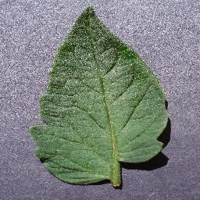


✅ Ground Truth (first 300 chars):
The observation results show that the leaves in this picture are Healthy and do not show any abnormal symptoms....

🎯 Fine-Tuned Model:
Based on observation, I believe this is Tomato target spot. Symptoms of Tomato target spot: On the leaves, the disease first manifests as small necrotic lesions, with a light brown center and dark edges. The symptoms usually start deep in the tomato tree crown. On the fruit, the lesion first manifests as brown, slightly depressed spots. As the disease progresses, large areas of depression will appear on the fruit.<|im_end|>

📝 Test Sample (index 49996)


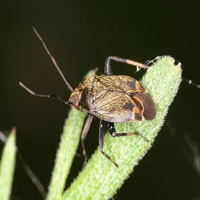


✅ Ground Truth (first 300 chars):
I observe that this is Miridae. Miridae has a variety of body colors, ranging from gray, yellow, brown, black to bright green, orange, red, etc. Some species have distinct flower spots. The body shape is also quite diverse, most of which are long ellipses or ellipses; Some groups are spindle shaped ...

🎯 Fine-Tuned Model:
Based on observation, I confirm that this is a species of Miridae. Miridae has a variety of body colors, ranging from gray, yellow, brown, black to bright green, orange, red, etc. Some species have distinct flower spots. The body shape is also quite diverse, most of which are long ellipses or ellipses; Some groups are spindle shaped and adapt to live on narrow leaved grasses; There are also several species of ant mimics, with the base of their head constricted into a neck shape, and the base of their abdomen and wings narrow into a waist shape, resulting in a similar appearance to ants. Nymphites also have similar mimicry. Miridae's

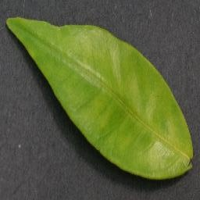


✅ Ground Truth (first 300 chars):
Based on my observation, there are yellow green patches around the veins of the leaves in this picture, which have an irregular shape. These manifestations may be caused by Citrus greening. The harm of Citrus greening is manifested as root rot, which is symmetrical to the severity of aboveground bra...

🎯 Fine-Tuned Model:
From the image, it can be seen that the veins of the leaves gradually turn yellow and wither, and irregular, indistinct yellow green patches appear on the leaves scattered near the veins. These manifestations may be caused by Citrus greening. The harm of Citrus greening is manifested as root rot, which is symmetrical to the severity of aboveground branches. In the early stage of branch and leaf disease, the roots do not rot. When the leaves turn yellow and fall off, the fibrous roots and branch roots begin to rot, and later spread to the lateral and main roots. The cortex is broken and detached from the woody parts. Branches and tru

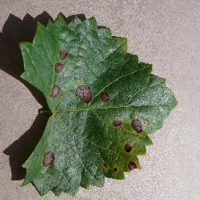


✅ Ground Truth (first 300 chars):
Observing this image, I find a large number of well - defined red brown small spots on the leaves, with the center of the spots appearing gray brown and the edges appearing black brown. This phenomenon indicates that it may be caused by Black rot of grapes. Black rot of grapes mainly occurs on fruit...

🎯 Fine-Tuned Model:
Based on the image, it can be seen that there are many well - defined red brown small spots on the leaves, which are nearly circular and scattered on the leaves. The center is gray brown, the outer edge is brown, and the edges are black brown. This abnormal symptom is actually caused by Black rot of grapes. Black rot of grapes mainly occurs on fruits, leaves, petioles, and new shoots. After the fruit is damaged, small purple brown spots appear in the early stage of disease, gradually expanding into brown edges, gray white in the center, slightly concave. The diseased fruit is soft and rotten, and then becomes dry and stiff, with obv

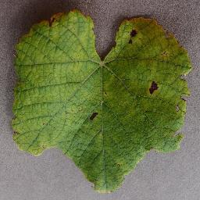


✅ Ground Truth (first 300 chars):
Some clearly define dark spots can be seen on the leaves. These spots may be caused by Leaf blight of grape. Symptoms of Leaf Blight of Grape: In the early stage of the disease, the leaf first turns yellow, and the yellow part gradually turns brown and necrotic. Expanding locally to the entire leaf ...

🎯 Fine-Tuned Model:
I notice dark spots on the leaves, which are irregularly shaped and clearly visible. These spots may be caused by Leaf blight of grape. Symptoms of Leaf Blight of Grape: In the early stage of the disease, the leaf first turns yellow, and the yellow part gradually turns brown and necrotic. Expanding locally to the entire leaf vein, presenting brown to reddish brown leaf edge lesions with wavy edges and darker colors. The boundary between disease and health is obvious, and sometimes there are yellow light bands of varying widths on the outer edge. Subsequently, the lesion gradually extends towards the base of the leaf until the entire

In [17]:
from transformers import TextStreamer

FastVisionModel.for_inference(model)

# Test on samples the model has NOT seen (from end of dataset)
test_indices = list(range(len(dataset)-5, len(dataset)))

for idx in test_indices:
    image = dataset[idx]["image"]
    gt = dataset[idx]["text"][:300]

    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": INSTRUCTION},
        ]}
    ]

    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tokenizer(
        image, input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    print(f"\n{'='*80}")
    print(f"📝 Test Sample (index {idx})")
    display(image.resize((200, 200)))
    print(f"\n✅ Ground Truth (first 300 chars):\n{gt}...")
    print(f"\n🎯 Fine-Tuned Model:")

    text_streamer = TextStreamer(tokenizer, skip_prompt=True)
    _ = model.generate(
        **inputs,
        streamer=text_streamer,
        max_new_tokens=300,
        use_cache=True,
        temperature=1.5,
        min_p=0.1,
    )

## 9 - Push Final Model to Hub (LoRA Adapter)

In [18]:
# Push the final LoRA adapter as a standalone model repo
FINAL_MODEL_REPO = f"{HF_USERNAME}/Plant-Disease-Qwen3VL-2B-LoRA"

model.push_to_hub_merged(
    FINAL_MODEL_REPO,
    tokenizer,
    save_method="lora",
)
print(f"✅ Final LoRA adapter pushed to: {FINAL_MODEL_REPO}")

config.json: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.



Unsloth: Preparing safetensor model files:   0%|                                         | 0/1 [00:00<?, ?it/s]

...


Unsloth: Merging weights into 16bit:   0%|                                               | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Unsloth: Merging weights into 16bit: 100%|███████████████████████████████████████| 1/1 [01:05<00:00, 65.48s/it]


Unsloth: Merge process complete. Saved to `/root/Rady10/Plant-Disease-Qwen3VL-2B-LoRA`
✅ Final LoRA adapter pushed to: Rady10/Plant-Disease-Qwen3VL-2B-LoRA


In [19]:
# Push the final merged model as a standalone model repo
FINAL_MODEL_REPO = f"{HF_USERNAME}/Plant-Disease-Qwen3VL-2B"

model.push_to_hub_merged(
    FINAL_MODEL_REPO,
    tokenizer,
    save_method="merged_16bit",
)
print(f"✅ Final merged model pushed to: {FINAL_MODEL_REPO}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.



Unsloth: Preparing safetensor model files:   0%|                                         | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

...


Unsloth: Merging weights into 16bit:   0%|                                               | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Unsloth: Merging weights into 16bit: 100%|███████████████████████████████████████| 1/1 [00:29<00:00, 29.62s/it]


Unsloth: Merge process complete. Saved to `/root/Rady10/Plant-Disease-Qwen3VL-2B`
✅ Final merged model pushed to: Rady10/Plant-Disease-Qwen3VL-2B


## Summary

| Item | Detail |
|------|--------|
| **Model** | Qwen3-VL-2B-Instruct |
| **Dataset** | Rady10/Plant-Diseases-Image-Text-Pairs |
| **Samples** | 50,000 (5 × 10K chunks) |
| **Framework** | Unsloth (QLoRA 4-bit) |
| **LoRA Config** | r=16, alpha=16, target=all-linear |
| **Training** | 1 epoch per chunk, batch=2, grad_accum=4 |
| **Checkpoints** | Pushed to HF Hub after every round |

### Saved Adapters (Local + 🤗 Hub)
- `round_1` → after 10K samples
- `round_2` → after 20K samples
- `round_3` → after 30K samples
- `round_4` → after 40K samples
- `round_5` → after 50K samples
- `final_50k` → final combined adapter

### Resume from Failure
Simply re-run the notebook. It will automatically detect completed rounds on the Hub and skip them.